In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas
import numpy
import matplotlib.pyplot as plt
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets
y = y['class']
y = y.astype('object')

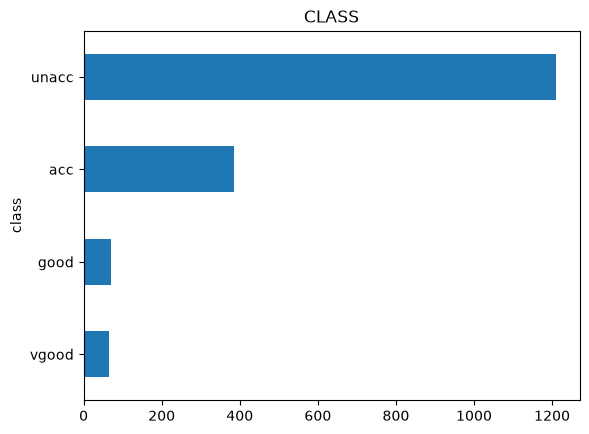

In [2]:
#Y

y.value_counts().sort_values().plot.barh(title='CLASS')

plt.show()

In [3]:
X.head()

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med


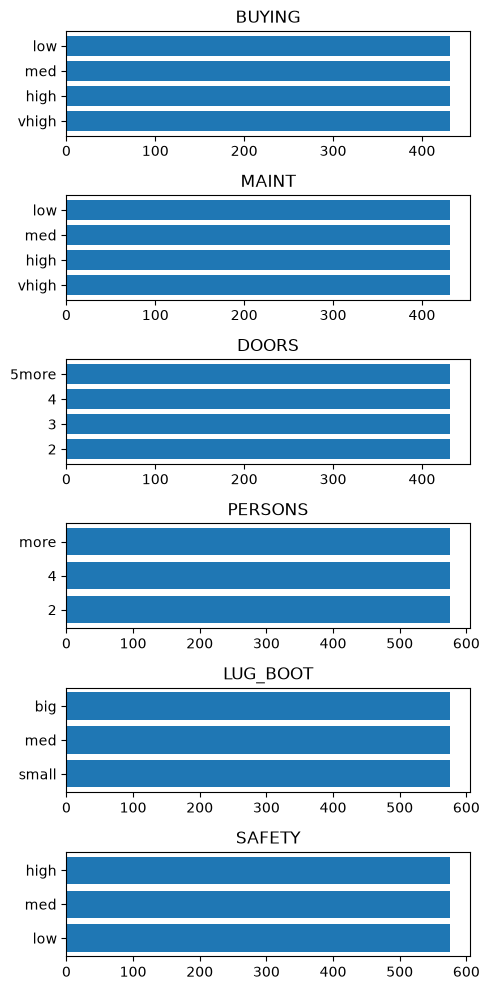

In [4]:
fig, ax = plt.subplots(6, 1, figsize=(5,10))

i = 0
for col in X.columns:
    count = X[col].value_counts().sort_values()
    ax[i].barh(count.index, count.values)
    ax[i].set_title(col.upper())
    i += 1
plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

mapping ={
    'buying' : {'low':0, 'med':1, 'high':2, 'vhigh':3},
    'maint' : {'low':0, 'med':1, 'high':2, 'vhigh':3},
    'doors' : {'2':2, '3':3, '4':4, '5more':5},
    'persons' : {'2':2, '4':4, 'more':6},
    'lug_boot' : {'small':0, 'med':1, 'big':2},
    'safety' : {'low':0, 'med':1, 'high':2}
}

for key, value in mapping.items():
    X[key] = X[key].map(value)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.3, stratify=y, random_state=42)

y_train.value_counts()/sum(y_train.value_counts().values)

class
unacc    0.700579
acc      0.222498
good     0.039702
vgood    0.037221
Name: count, dtype: float64

In [7]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 1, 200)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 100, 1000)
    
    tree = DecisionTreeClassifier(
        max_depth = max_depth,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_leaf_nodes = max_leaf_nodes,
        random_state=42)
    
    score = cross_val_score(tree, X_train, y_train, cv=4, n_jobs=-1,scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)
print(f'{study.best_params}\nResult: {study.best_value}')

{'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 583}
Result: 0.9760152339737285


In [8]:
tree = DecisionTreeClassifier(**study.best_params)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

accuracy_score(y_test, y_pred)

0.9845857418111753

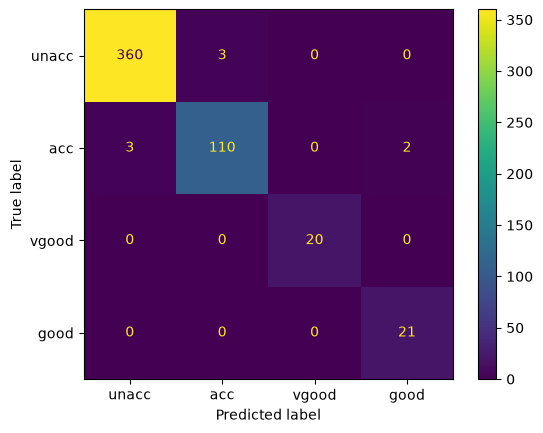

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=y.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y.unique())
disp.plot()
plt.show()

In [11]:
from sklearn.model_selection import cross_validate

cross_validate(tree, X_train, y_train, cv=4, n_jobs=-1,
                        scoring=['accuracy','f1_micro', 'f1_macro', 'f1_weighted']) 

{'fit_time': array([0.00214982, 0.00328827, 0.00326967, 0.00476313]),
 'score_time': array([0.00599766, 0.00918698, 0.0089066 , 0.00890613]),
 'test_accuracy': array([0.97689769, 0.98013245, 0.97350993, 0.97350993]),
 'test_f1_micro': array([0.97689769, 0.98013245, 0.97350993, 0.97350993]),
 'test_f1_macro': array([0.95243257, 0.9581315 , 0.95071228, 0.92374687]),
 'test_f1_weighted': array([0.97669093, 0.98036552, 0.97325348, 0.97514067])}

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.97      0.96      0.96       115
        good       0.91      1.00      0.95        21
       unacc       0.99      0.99      0.99       363
       vgood       1.00      1.00      1.00        20

    accuracy                           0.98       519
   macro avg       0.97      0.99      0.98       519
weighted avg       0.98      0.98      0.98       519

